In [1]:
import tensorflow as tf
tf.random.set_seed(101)
import numpy as np
np.random.seed(101)
import keras
keras.backend.clear_session()
import time
from random import choice
import argparse
import json
import pandas as pd
from datetime import datetime
import matplotlib.pyplot as plt
from tensorflow.keras import optimizers
from tensorflow.keras.layers import Dense
from tensorflow.keras.models import Sequential
from tensorflow.keras.optimizers import SGD
from tensorflow.keras.layers import Dense, Layer
import warnings
warnings.filterwarnings('ignore')


## Parámetros

In [2]:

NUM_GPUS = 1
BS_PER_GPU = 64  # Cantidad de ejemplos por lote por GPU. En este caso, se establece en 64, 
                 # aunque podría ser 128.

# Definición del dispositivo
# device_name = '/gpu:0'  # Si se utiliza una GPU específica
device_name = '/cpu:0'  # Si se utiliza101a CPU

# Configuración de los argumentos de línea de comandos
parser = argparse.ArgumentParser()
parser.add_argument("-d", "--dataset", choices=["chile", "colombia", "lebanon", "georgia"], default="chile", required=False)
parser.add_argument("-e", "--epochs", default=20, type=int, required=False)
parser.add_argument("-m", "--min", default=10, type=int, required=False) # Cantidad minima de votaciones por usuario
parser.add_argument("-ps", "--space", default=2, type=int, required=False)  # Dimension de la capa de embedding. Para coordenadas bidimensionales debe ser 2
parser.add_argument("-s", "--subset", default=999999, type=int, required=False) # Cantidad máxima de usuarios de la base de datos
parser.add_argument("-t", "--type", default="default", type=str, required=False) # Tipo de modelo en la arquitectura. Como se definieron las funciones con los parámetros que estaban por defecto, este parámetro no se utiliza.
parser.add_argument("-f", required=False)
args = parser.parse_args()


# Asignación de los argumentos a variables correspondientes
DATASET = args.dataset
NUM_EPOCHS = args.epochs
MINIMUM_NUMBER_VOTES = args.min
NUMBER_SELECTED_USERS = args.subset
DIM_POLITICAL_SPACE = args.space 
MODEL_TYPE = args.type

# Diccionario para las propiedades del modelo
now = datetime.now()
dateString = now.strftime('%d/%m/%Y %H:%M:%S').replace(' ', '_').replace('/', '_').replace(':', '_')
MODEL_LABEL = f'{DATASET}_{dateString}'  # Nombre con el que se guardará el modelo

# Configuración de rutas de salida 
model_properties_path = f'results/models/model_properties_{MODEL_LABEL}.json'
model_properties = {'model_label': MODEL_LABEL, 'dateString': dateString, 'DATASET': DATASET}

trained_model_path = f'results/models/model_{MODEL_LABEL}'
option_map_path = f'results/models/optionMap_{MODEL_LABEL}.csv'
coordsP_path = f'results/coordsP/{MODEL_LABEL}.csv'
coordsU_path = f'results/coordsU/{MODEL_LABEL}.csv'

# Diccionario para las propiedades del modelo
model_properties['trained_model_path'] = trained_model_path
model_properties['option_map_path'] = option_map_path
model_properties['coordsP_path'] = coordsP_path
model_properties['coordsU_path'] = coordsU_path  

model_properties['NUMBER_SELECTED_USERS'] = NUMBER_SELECTED_USERS
model_properties['MINIMUM_NUMBER_VOTES'] = MINIMUM_NUMBER_VOTES
model_properties['NUM_GPUS'] = NUM_GPUS
model_properties['BS_PER_GPU'] = BS_PER_GPU
model_properties['NUM_EPOCHS'] = NUM_EPOCHS


print('------')
print('MODEL_LABEL:', MODEL_LABEL)
print('Model properties path:', model_properties_path)
print('Proposal Coordinates path:', coordsP_path)
print('User Coordinates path:', coordsU_path)
print('------')


------
MODEL_LABEL: chile_10_09_2024_16_28_14
Model properties path: results/models/model_properties_chile_10_09_2024_16_28_14.json
Proposal Coordinates path: results/coordsP/chile_10_09_2024_16_28_14.csv
User Coordinates path: results/coordsU/chile_10_09_2024_16_28_14.csv
------


## Lectura de datos

In [3]:
df = pd.read_csv('data/Pair_Wise_Nominate_Todos_usuarios.csv')

## División base de datos

In [4]:
def makeX(uuid,a,b,optionMap,userMap):
    return (list(optionMap[a])+list(userMap[uuid])+list(optionMap[b]))

def formatData(df, testFraction=0.1, method='index', path=None, optionMap=None):
    '''
    Realiza la división de los datos en conjuntos de entrenamiento y prueba.
     
    Parameters
    ----------
    df: pandas.DataFrame
        Tabla con columnas: uuid, option_a, option_b, selected.
        Genera la variable Y (indica si selected == option_a).

    testFraction: float
        Fracción de datos que se dejará para la prueba.

    path: str (opcional)
        Si no es None, guarda el optionMap en la ruta especificada como un archivo csv.
        Por favor, agregar la extensión csv.
    '''

    # Conjunto de opciones y usuarios únicos en el DataFrame
    optionSet = set(df['option_a']) | set(df['option_b'])
    userSet = set(df['uuid'])

    # Número de opciones y usuarios únicos
    nOptions = len(optionSet)
    nUsers = len(userSet)

    # Generar la variable de resultado Y. Es 1 si la opción seleccionada es a, 0 si es b.
    if 'Y' not in df.columns:
        df['Y'] = 0  # La variable de resultado es 0.
        df.loc[df['selected'] == df['option_a'], 'Y'] = 1

    # Generar un mapa de las propuestas en relación a su indice
    if optionMap is None:
        optionMap = {o: [i] for i, o in enumerate(sorted(list(optionSet)))}
    userMap = {o: [i] for i, o in enumerate(sorted(list(userSet)))}

    # Guardar el optionMap en un archivo CSV si se especifica una ruta (path)
    if (path is not None) and (method == 'index'):
        optionMapDf = pd.DataFrame([(o, optionMap[o][0]) for o in optionMap], columns=['option', 'index'])
        optionMapDf.to_csv(path, index=False)

    # Crear la matriz X con listas [[option a],[uuid],[óption b]]
    # y el vector Y con 1 si la opción seleccionada es a, y 0 caso contrario.
    X = [makeX(uuid, a, b, optionMap, userMap) for uuid, a, b in df[['uuid', 'option_a', 'option_b']].values]
    X = np.array(X)
    Y = df['Y'].values

    # A continuación se dividirá aleatoriamente los datos en entrenamiento y prueba
    # Inicializar dos listas vacías para almacenar los indices de los registros de entrenamiento y prueba
    id_test = []
    id_train = []
    # Agrupar el conjunto de datos por la columna "uuid"
    df = df.reset_index()
    df_user_a = df.groupby('uuid')

    # Iterar sobre cada grupo de usuario
    for name, df_user in df_user_a:

        # Se guarda y mezcla de manera aleatoria los indices de cada usuario.
        i = np.array(df_user.index)
        #np.random.shuffle(i)

        # Dividir el arreglo en dos subconjuntos, uno para entrenamiento y otro para prueba, con una proporción según el valor
        # de testFraction.
        train, test = np.split(i, [int(len(i) * (1-testFraction))])

        # Agregar los indices correspondientes a los registros de entrenamiento y prueba a las listas
        id_train.append(train)
        id_test.append(test)



    # Aplanar las listas de indices de registros de entrenamiento y prueba
    id_train = [item for sublist in id_train for item in sublist]
    id_test = [item for sublist in id_test for item in sublist]

    
    # Se separa la base de entrenamiento y test según los indices que contienen id_train y id_test.
    X_test = X[id_test]
    Y_test = Y[id_test]
    X = X[id_train]
    Y = Y[id_train]

    return X, Y, X_test, Y_test, optionMap, userMap


In [5]:
# Prepara los datos para tensorflow

print('Formateando los datos para TensorFlow')
nOptions = len(set(df['option_a']) | set(df['option_b']))  # Número total de opciones
nUsers = len(set(df['uuid']))  # Número de usuarios
model_properties['nOptions'] = nOptions
model_properties['nUsers'] = nUsers

# Divide la base de datos de entrenamiento y test. Con el parámetro testFraction se define las proporciones del tamaño
# de la base de test.
X, Y, X_test, Y_test, optionMap, userMap = formatData(df, testFraction=0.1, method='index', path=option_map_path)


SIZE_INPUT_LAYER = np.shape(X)[-1]
NUM_TRAIN_SAMPLES = len(Y)

# Se convierte los tensores X e Y en un dataset que puede ser utilizado para alimentar los datos
# al modelo de TensorFlow durante el entrenamiento y la evaluación.
train_dataset = tf.data.Dataset.from_tensor_slices((X, Y))
# Se mezcla el dataset de entrenamiento y se dividen en lotes de tamaño
train_dataset = train_dataset.shuffle(NUM_TRAIN_SAMPLES).batch(BS_PER_GPU * NUM_GPUS, drop_remainder=True).repeat()

# Se realiza el mismo procedimiento para la base de test.
test_dataset = tf.data.Dataset.from_tensor_slices((X_test, Y_test))
test_dataset = test_dataset.batch(BS_PER_GPU * NUM_GPUS, drop_remainder=True).repeat()


Formateando los datos para TensorFlow


In [6]:
print('\033[1m'+'Entrenamiento:'+'\033[0m')
print('\033[1m'+'X:'+'\033[0m'+str(X[0]))
print('\033[1m'+'Y: '+'\033[0m'+str(Y[0]))
print('')
print('\033[1m'+'Test:'+'\033[0m')
print('\033[1m'+'X_test:'+'\033[0m'+str(X_test[0]))
print('\033[1m'+'Y_test: '+'\033[0m'+str(Y_test[0]))

Entrenamiento:
X:[86  0 43]
Y: 0

Test:
X_test:[46  0 62]
Y_test: 1


## Arquitectura del modelo

In [7]:
# Clase de la primera capa de la arquitectura
class PoliticalCoords(Layer):
    def __init__(self,dimPoliticalSpace=2, nOptions=90, nUsers=100, activation='linear', initializer_stddev=0.05, initializer_seed=101):
        '''
        Toma una capa con índices.
        Supone que la entrada está ordenada como Opción A, Usuario, Opción B.
        Retorna en el mismo orden.

        Parámetros
        ----------
        initializer_stddev: float (default=0.05)
            Las coordenadas se inicializan utilizando un inicializador random_normal con media cero. 
            Este parámetro establece la desviación estándar.
        initializer_seed: int (default=101)
            Semilla del inicializador para asegurar consistencia en la comparación entre modelos.
        '''
        super(PoliticalCoords, self).__init__()


        self.nOptions           = nOptions
        self.nUsers             = nUsers
        self.activation         = activation
        self.dimPoliticalSpace  = dimPoliticalSpace
        self.initializer_seed   = initializer_seed
        self.initializer_stddev = initializer_stddev

        wp_init = tf.random_normal_initializer(mean=0.0, stddev=self.initializer_stddev, seed=self.initializer_seed)
        wu_init = tf.random_normal_initializer(mean=0.0, stddev=self.initializer_stddev, seed=self.initializer_seed)
        self.wp = tf.Variable(initial_value=wp_init(shape=(self.nOptions, self.dimPoliticalSpace),dtype='float32'),
                         trainable=True)
        self.wu = tf.Variable(initial_value=wu_init(shape=(self.nUsers, self.dimPoliticalSpace),dtype='float32'),
                         trainable=True)

    def call(self, inputs):
        """
        Realiza el cálculo de la coordenadas politicas utilizando una capa de embedding.
        """
        
        inputs = tf.cast(inputs,'int32')
        za = tf.nn.embedding_lookup(self.wp, inputs[:,:1])[:,0,:]
        zu = tf.nn.embedding_lookup(self.wu, inputs[:,1:2])[:,0,:]
        zb = tf.nn.embedding_lookup(self.wp, inputs[:,2:])[:,0,:]
        z = tf.concat([za,zu,zb],1)
        return tf.nn.sigmoid(z)

    def returnOptionsEmbedding(self, withActivation=True):
        '''
        Devuelve las coordenadas políticas de las opciones.
        '''
        z = self.wp
        return tf.nn.sigmoid(z)

    def returnUsersEmbedding(self, withActivation=True):
        '''
        Devuelve las coordenadas políticas de los usuarios.
        '''
        z = self.wu     
        return tf.nn.sigmoid(z)
    
    
class NOM_original(Layer):
    def __init__(self, dimPoliticalSpace=32,  symmetric=True, neuronas=10, initializer_stddev = 0.05,initializer_seed=101):
        '''
        Implementa la función NOMINATE como una suma ponderada de las distancias.
        Se asume que la entrada está ordenada como Opción A, Usuario, Opción B.
        Esta capa debe estar conectada a la capa PoliticalCoords.
        Esta capa siempre devolverá un tensor de forma (1,2), independientemente de la dimensión 
        del espacio político.

        Parameters
        ----------
        dimPoliticalSpace: int
            Dimensión del espacio de coordenadas políticas (dimensión del embedding).
        activation: str
            Función de activación. El NOMINATE estándar utiliza 'exp'.
        symmetric: booleano (default=True)
            Si es False, la métrica del espacio político será diferente al comparar A con U 
            que al comparar U con A.
        weightsType: str ('linear', 'square', o None)
            Tipo de pesos a utilizar como métrica para el espacio político. Si es None, se asume
            que el espacio político es plano.
        '''
        super(NOM_original, self).__init__()    

        self.dimPoliticalSpace = dimPoliticalSpace
        self.neuronas          = neuronas
        self.symmetric         = symmetric
        self.initializer_seed  = initializer_seed
        self.initializer_stddev = initializer_stddev
        
        
        if self.symmetric:
            if neuronas%2!=0:
                print('Neuronas debe ser par')
        
            w_init = tf.random_normal_initializer(seed=self.initializer_seed,stddev=self.initializer_stddev,)
            self.w = tf.Variable(initial_value=w_init(shape=(dimPoliticalSpace, int(neuronas/2)),dtype='float32'),
                                  trainable=True)
            b_init = tf.random_normal_initializer(seed=self.initializer_seed)
            self.b = tf.Variable(initial_value=b_init(shape=(1,int(neuronas/2)),dtype='float32'),
                                 trainable=True)
        
        else:
            wa_init = tf.random_normal_initializer(seed=self.initializer_seed,stddev=self.initializer_stddev)
            self.wa = tf.Variable(initial_value=wa_init(shape=(dimPoliticalSpace, int(neuronas/2)),dtype='float32'),
                              trainable=True)
            wb_init = tf.random_normal_initializer(seed=self.initializer_seed,stddev=self.initializer_stddev)
            self.wb = tf.Variable(initial_value=wb_init(shape=(dimPoliticalSpace, int(neuronas/2)),dtype='float32'),
                                      trainable=True)
            b_init = tf.random_normal_initializer(seed=self.initializer_seed,stddev=self.initializer_stddev)
            self.b = tf.Variable(initial_value=b_init(shape=(1,neuronas),dtype='float32'),
                         trainable=True)

   
       
    def call(self, inputs):
        """
        Realiza el cálculo de la función NOMINATE para una entrada dada  utilizando las coordenadas
        políticas, los pesos y los términos de sesgo definidos en la capa. El procedimiento consiste
        en tomar las coordenadas políticas de la opción A, el usuario y la opción B, y calcular las
        distancias al usuario. Luego, se realiza una multiplicación matricial con los pesos w, se 
        realiza una concatenación y se agrega un término de sesgo b. Finalmente, se aplica la función
        de activación exponencial (exp) a la salida.
        """
        xa = inputs[:,:self.dimPoliticalSpace]
        xu = inputs[:,self.dimPoliticalSpace:self.dimPoliticalSpace*2]
        xb = inputs[:,self.dimPoliticalSpace*2:]

        da = tf.math.square(tf.math.subtract(xa,xu))
        db = tf.math.square(tf.math.subtract(xb,xu))

        if self.symmetric:
          
            za = tf.matmul(da, self.w)
            zb = tf.matmul(db, self.w)
            z = tf.concat([za,zb],1) 
            z = z +  tf.concat([self.b,self.b],1) 
        else:
           
            za = tf.matmul(da, self.wa)
            zb = tf.matmul(db, self.wb)
            z = tf.concat([za,zb],1) + self.b
        return tf.exp(z)

    def returnSpaceWeights(self):
        '''
        Devuelve las coordenadas políticas de las propuestas
        '''
        if self.symmetric:
            return self.w
        else:
            return [self.wa,self.wb]


          
class DENSE_original(Layer):
    def __init__(self,neuronas=10, symmetric=True, initializer_seed=101):
        '''
        Implementa la función NOMINATE como una suma ponderada de las distancias.
        Se asume que la entrada está ordenada como Opción A, Usuario, Opción B.
        Esta capa debe estar conectada a la capa PoliticalCoords.
        Esta capa siempre devolverá un tensor de forma (1,2), independientemente de la dimensión 
        del espacio político.

        Parameters
        ----------
        dimPoliticalSpace: int
            Dimensión del espacio de coordenadas políticas (dimensión del embedding).
        activation: str
            Función de activación. El NOMINATE estándar utiliza 'exp'.
        symmetric: booleano (default=True)
            Si es False, la métrica del espacio político será diferente al comparar A con U 
            que al comparar U con A.
        weightsType: str ('linear', 'square', o None)
            Tipo de pesos a utilizar como métrica para el espacio político. Si es None, se asume
            que el espacio político es plano.
        '''
        super(DENSE_original, self).__init__()    


        self.symmetric         = symmetric
        self.neuronas          = neuronas
        self.initializer_seed  = initializer_seed
        
        if neuronas%2!=0:
            print('Neuronas tiene que ser par')
        
        if self.symmetric:

            w_init = tf.random_normal_initializer(seed=self.initializer_seed)
            self.w = tf.Variable(initial_value=w_init(shape=(int(neuronas/2), 1),dtype='float32'),
                                  trainable=True)
            b_init = tf.random_normal_initializer(seed=self.initializer_seed)
            self.b = tf.Variable(initial_value=b_init(shape=(1,1),dtype='float32'),
                                 trainable=True)
        
        else:
            wa_init = tf.random_normal_initializer(seed=self.initializer_seed)
            self.wa = tf.Variable(initial_value=wa_init(shape=(int(neuronas/2), 1),dtype='float32'),
                              trainable=True)
            wb_init = tf.random_normal_initializer(seed=self.initializer_seed)
            self.wb = tf.Variable(initial_value=wb_init(shape=(int(neuronas/2), 1),dtype='float32'),
                                      trainable=True)
            b_init = tf.random_normal_initializer(seed=self.initializer_seed)
            self.b = tf.Variable(initial_value=b_init(shape=(1,2),dtype='float32'),
                         trainable=True)

    def call(self, inputs):
        """
        Realiza el cálculo de la función NOMINATE para una entrada dada  utilizando las coordenadas
        políticas, los pesos y los términos de sesgo definidos en la capa. El procedimiento consiste
        en tomar las coordenadas políticas de la opción A, el usuario y la opción B, y calcular las
        distancias al usuario. Luego, se realiza una multiplicación matricial con los pesos w, se 
        realiza una concatenación y se agrega un término de sesgo b. Finalmente, se aplica la función
        de activación exponencial (exp) a la salida.
        """
        da = inputs[:,:int(self.neuronas/2)]
        db = inputs[:,int(self.neuronas/2):]


        if self.symmetric:
          
            za = tf.matmul(da, self.w)
            zb = tf.matmul(db, self.w)
            z = tf.concat([za,zb],1) 
            z = z +  tf.concat([self.b,self.b],1) 
        else:
           
            za = tf.matmul(da, self.wa)
            zb = tf.matmul(db, self.wb)
            z = tf.concat([za,zb],1) + self.b
        return tf.exp(z)

    def returnSpaceWeights(self):
        '''
        Devuelve las coordenadas políticas de las propuestas
        '''
        if self.symmetric:
         
            return self.w
        else:
           
            return [self.wa,self.wb]
       
    

def get_model_original(model_type=None, dimPoliticalSpace=2, nOptions=90, nUsers=100):
    '''
    Arquitectura compuetsa por una capa de embedding, capa oculta de 8 neuronas, capa oculpta de 2 neuronas y una capa de salida
    de una neurona.
    Parámetros
    ----------
    model_type: str (opcional)
        Podemos definir múltiples modelos y seleccionarlos con este parámetro.
    '''
    model = Sequential([
        PoliticalCoords(nOptions=nOptions, nUsers=nUsers, dimPoliticalSpace=dimPoliticalSpace, activation='sigmoid', initializer_stddev=0.05),
        NOM_original(dimPoliticalSpace=dimPoliticalSpace, neuronas =8, symmetric=True),
        DENSE_original(neuronas=8, symmetric=True),
        Dense(1, activation='sigmoid'),
    ])
  
    return model
                          
     

In [8]:
print('Preparing model')
model_properties['DIM_POLITICAL_SPACE'] = DIM_POLITICAL_SPACE 
model_properties['model_type'] = MODEL_TYPE

# Se define el modelo
model = get_model_original(model_type=MODEL_TYPE, dimPoliticalSpace=DIM_POLITICAL_SPACE, nOptions=nOptions, nUsers=nUsers)


Preparing model


## Entrenamiento

**A continuación se compila y entrena el modelo**

In [9]:
adamax_opt = tf.keras.optimizers.experimental.Adamax(learning_rate=0.01)

with tf.device(device_name):
    # Compilar el modelo
    model.compile(
        loss=tf.keras.losses.BinaryCrossentropy(),  # Función de pérdida para clasificación binaria
        optimizer=adamax_opt,  # Optimizador Adamax con LR especificado
        metrics=['accuracy']  # Métrica de precisión
    )

    # Medir el tiempo de entrenamiento
    start_time = time.time()  # Iniciar el cronómetro

    history = model.fit(
        train_dataset,  # Conjunto de entrenamiento
        epochs=NUM_EPOCHS,  # Número de épocas
        steps_per_epoch=NUM_TRAIN_SAMPLES // BS_PER_GPU,  # Número de pasos por época
        validation_steps=len(Y_test) // BS_PER_GPU,  # Pasos de validación
        validation_data=test_dataset,  # Conjunto de validación
        verbose=2  # Nivel de detalle de los mensajes
    )

    end_time = time.time()  # Parar el cronómetro

    # Calcular el tiempo total de entrenamiento
    training_time = end_time - start_time
    print('')
    print(f"Tiempo total de entrenamiento: {training_time:.2f} segundos")


Epoch 1/20
41929/41929 - 51s - loss: 0.6068 - accuracy: 0.6664 - val_loss: 0.6055 - val_accuracy: 0.6683 - 51s/epoch - 1ms/step
Epoch 2/20
41929/41929 - 56s - loss: 0.5866 - accuracy: 0.6843 - val_loss: 0.5967 - val_accuracy: 0.6765 - 56s/epoch - 1ms/step
Epoch 3/20
41929/41929 - 62s - loss: 0.5742 - accuracy: 0.6947 - val_loss: 0.5909 - val_accuracy: 0.6831 - 62s/epoch - 1ms/step
Epoch 4/20
41929/41929 - 65s - loss: 0.5669 - accuracy: 0.7023 - val_loss: 0.5884 - val_accuracy: 0.6852 - 65s/epoch - 2ms/step
Epoch 5/20
41929/41929 - 67s - loss: 0.5631 - accuracy: 0.7057 - val_loss: 0.5875 - val_accuracy: 0.6855 - 67s/epoch - 2ms/step
Epoch 6/20
41929/41929 - 69s - loss: 0.5607 - accuracy: 0.7079 - val_loss: 0.5871 - val_accuracy: 0.6861 - 69s/epoch - 2ms/step
Epoch 7/20
41929/41929 - 71s - loss: 0.5588 - accuracy: 0.7094 - val_loss: 0.5883 - val_accuracy: 0.6871 - 71s/epoch - 2ms/step
Epoch 8/20
41929/41929 - 75s - loss: 0.5558 - accuracy: 0.7120 - val_loss: 0.5826 - val_accuracy: 0.6898

## Evaluación

In [10]:
print('EVALUATE MODEL')

# Evaluar el modelo en el conjunto de datos de prueba
eva = model.evaluate(test_dataset, steps=len(Y_test) // BS_PER_GPU)

# Imprimir el puntaje de prueba y la precisión de prueba
print('Test Score: ', eva[0])
print('Test accuracy: ', eva[1])

# Guardar los valores de pérdida y precisión en las propiedades del modelo
model_properties['TEST_SCORE'] = float(str(eva[0]))
model_properties['TEST_ACCURACY'] = float(str(eva[1]))


EVALUATE MODEL
5066/5066 [==============================] - 4s 796us/step - loss: 0.5860 - accuracy: 0.6892
Test Score:  0.5860119462013245
Test accuracy:  0.6891624331474304


**A continuación se realiza la visualización del modelo y se muestra un resumen del mismo.**

In [11]:
tf.keras.utils.plot_model(model, f'results/figures/sequential_{DATASET}_{dateString}.png', show_shapes=True)
model.summary()

You must install pydot (`pip install pydot`) and install graphviz (see instructions at https://graphviz.gitlab.io/download/) for plot_model to work.
Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 political_coords (Political  (64, 6)                  96418     
 Coords)                                                         
                                                                 
 nom_original (NOM_original)  (64, 8)                  12        
                                                                 
 dense_original (DENSE_origi  (64, 2)                  5         
 nal)                                                            
                                                                 
 dense (Dense)               (64, 1)                   3         
                                                                 
Total params: 96,438
Trainable params: 

**Se procederá a extraer y guardar la información de las coordenadas políticas de los usuarios y propuestas, así como los valores de los pesos del modelo.**

In [12]:
print('Saving values')

# Crear DataFrame de mapeo de índices de opciones
optionIndex = pd.DataFrame([(i, optionMap[i][0]) for i in optionMap], columns=['option_id', 'index'])
# Crear DataFrame de mapeo de índices de usuarios
userIndex = pd.DataFrame([(i, userMap[i][0]) for i in userMap], columns=['uuid', 'index'])

# Leer metadatos de usuarios desde un archivo CSV
userMetadata = pd.read_csv(f'data/data_people_dump_{DATASET}.csv')

# Leer metadatos de propuestas desde un archivo CSV o TSV
propsMetadata = pd.read_csv(f'data/labels/{DATASET}.tsv', delimiter='\t').rename(columns={'id': 'option_id'})

# Obtener las coordenadas de las propuestas del modelo
coordsP = model.layers[0].returnOptionsEmbedding().numpy()
# Combinar las coordenadas con el índice de opciones y convertirlo a DataFrame
coordsP = pd.merge(optionIndex, pd.DataFrame(coordsP, columns=['z' + str(i+1) for i in range(DIM_POLITICAL_SPACE)]).reset_index())


# Obtener las coordenadas de los usuarios del modelo
coordsU = model.layers[0].returnUsersEmbedding().numpy()
# Combinar las coordenadas con el índice de usuarios y convertirlo a DataFrame
coordsU = pd.merge(userIndex, pd.DataFrame(coordsU, columns=['z' + str(i+1) for i in range(DIM_POLITICAL_SPACE)]).reset_index())

# Combinar las coordenadas de usuarios con los metadatos de usuarios
#coordsU = pd.merge(userMetadata, coordsU)

# Guardar las coordenadas de las propuestas en un archivo CSV
coordsP.to_csv(coordsP_path, index=False)
# Guardar las coordenadas de los usuarios en un archivo CSV
coordsU.to_csv(coordsU_path, index=False)

# Guardar los pesos del modelo entrenado
model.save_weights(trained_model_path)

# Guardar las propiedades del modelo en un archivo JSON
model_properties['INITIAL_USER_COORDS'] = model.layers[0].returnUsersEmbedding().numpy().mean(0).tolist()
with open(model_properties_path, 'w') as fp:
    json.dump(model_properties, fp)

Saving values


**Finalmente se grafica el rendimiento del modelo durante el entrenamiento y la validación**

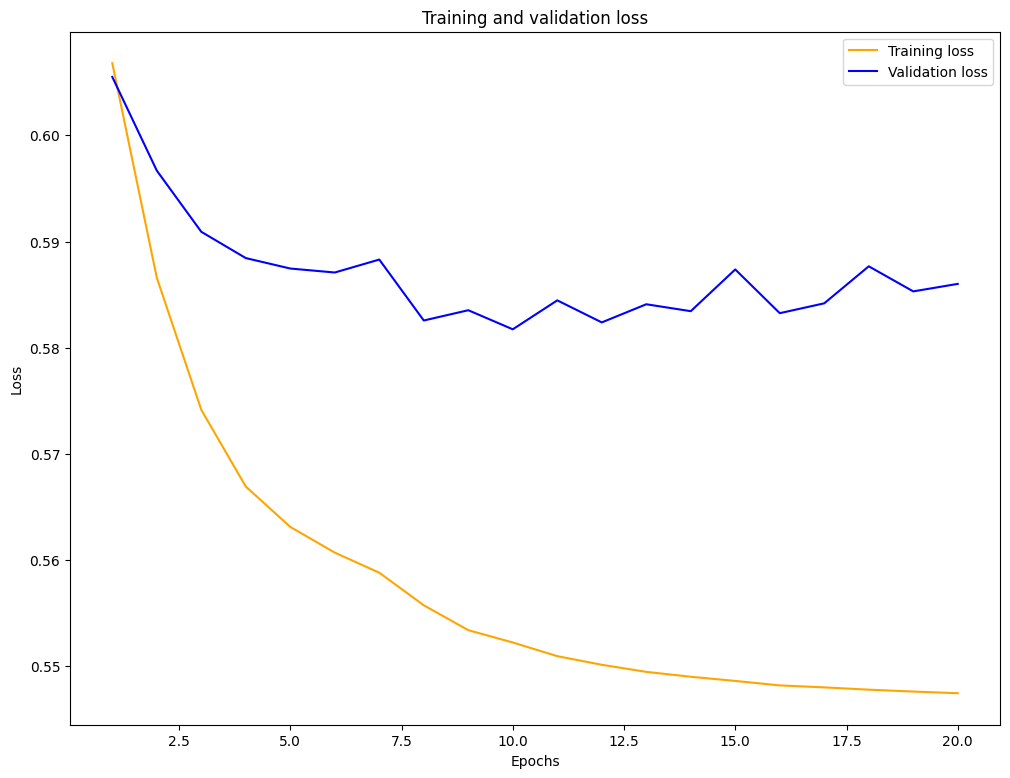

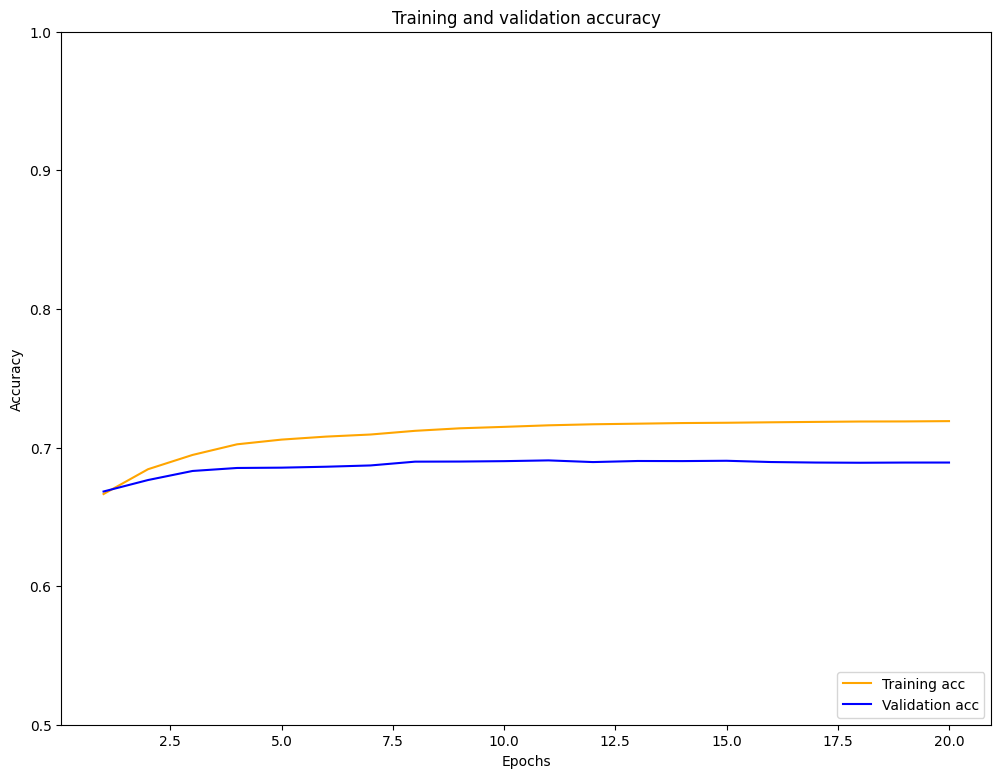

In [13]:
# Obtener los valores del historial de entrenamiento
history_dict = history.history
acc = history_dict['accuracy']
val_acc = history_dict['val_accuracy']
loss = history_dict['loss']
val_loss = history_dict['val_loss']
epochs = range(1, len(acc) + 1)

# Graficar la pérdida de entrenamiento y validación en función de las épocas (sin puntos)
plt.figure(figsize=(12, 9))
plt.plot(epochs, loss, color='orange', label='Training loss')  # Línea naranja para entrenamiento
plt.plot(epochs, val_loss, color='blue', label='Validation loss')  # Línea azul para validación
plt.title('Training and validation loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

# Graficar la precisión de entrenamiento y validación en función de las épocas (sin puntos)
plt.figure(figsize=(12, 9))
plt.plot(epochs, acc, color='orange', label='Training acc')  # Línea naranja para entrenamiento
plt.plot(epochs, val_acc, color='blue', label='Validation acc')  # Línea azul para validación
plt.title('Training and validation accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend(loc='lower right')
plt.ylim((0.5, 1))
plt.show()